Filename: cc48358.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      26   (50, 1024)   int16   

      METADATOS ESPECTROSCÓPICOS
Objeto/Lámpara:  Tung
Tipo de imagen:  flat
Telescopio:      1.88M
Instrumento:     cass-ccd
Red/Grating:     1800/56.35
Central Lambda:  6600 Å
Tiempo Expo:     4 s



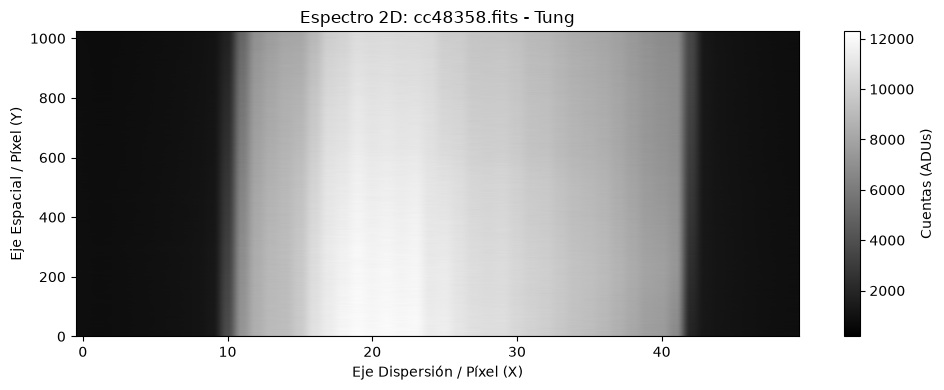

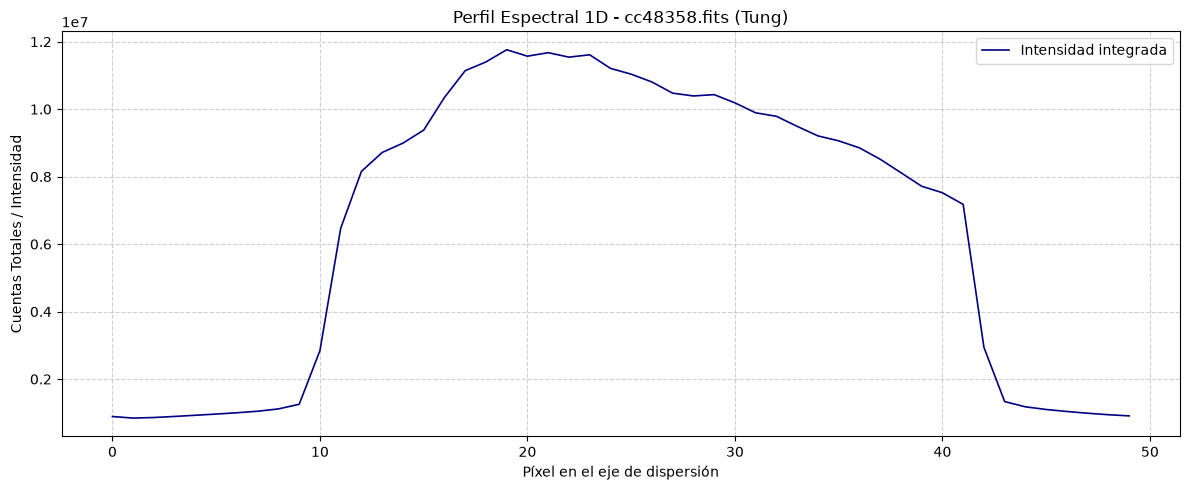

In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

def load_fits_data(filename):
    """
    Abre el archivo FITS y retorna la cabecera y la matriz de datos de la imagen 2D.
    """
    with fits.open(filename) as hdul:
        hdul.info()
        header = hdul[0].header.copy()
        data = hdul[0].data.astype(float)
    return header, data


def print_spectroscopic_metadata(header):
    """
    Muestra los metadatos relevantes para la reducción e identificación espectroscópica.
    """
    print("\n" + "=" * 40)
    print("      METADATOS ESPECTROSCÓPICOS")
    print("=" * 40)
    print(f"Objeto/Lámpara:  {header.get('OBJECT', 'N/A')}")
    print(f"Tipo de imagen:  {header.get('IMAGETYP', 'N/A')}")
    print(f"Telescopio:      {header.get('TELESCOP', 'N/A')}")
    print(f"Instrumento:     {header.get('INSTRUME', 'N/A')}")
    print(f"Red/Grating:     {header.get('GRATING', 'N/A')}")
    print(f"Central Lambda:  {header.get('CENT-LAM', 'N/A')} Å")
    print(f"Tiempo Expo:     {header.get('EXPTIME', 'N/A')} s")
    print("=" * 40 + "\n")


def plot_2d_spectrum(data, header, filename=""):
    """
    Visualiza el espectro bidimensional (detector CCD).
    """
    plt.figure(figsize=(10, 4))
    plt.imshow(data, cmap='gray', origin='lower', aspect='auto')
    plt.colorbar(label='Cuentas (ADUs)')
    plt.title(f"Espectro 2D: {filename} - {header.get('OBJECT', 'Sin nombre')}")
    plt.xlabel('Eje Dispersión / Píxel (X)')
    plt.ylabel('Eje Espacial / Píxel (Y)')
    plt.tight_layout()
    plt.show()


def extract_1d_spectrum(data, axis=0):
    """
    Colapsa la rendija/eje espacial para colapsar la señal a un espectro 1D de cuentas por píxel.
    
    Por defecto colapsa a lo largo del eje Y (axis=0), que corresponde
    a la dispersión en el eje X (1024 píxeles).
    """
    # Suma o promedio a lo largo de la rendija
    spectrum_1d = np.sum(data, axis=axis)
    pixels = np.arange(len(spectrum_1d))
    return pixels, spectrum_1d


def plot_1d_spectrum(pixels, intensity, header, filename=""):
    """
    Grafica el perfil espectral 1D (Intensidad vs Píxel).
    """
    plt.figure(figsize=(12, 5))
    plt.plot(pixels, intensity, color='navy', lw=1.2, label='Intensidad integrada')
    plt.title(f"Perfil Espectral 1D - {filename} ({header.get('OBJECT', 'N/A')})")
    plt.xlabel('Píxel en el eje de dispersión')
    plt.ylabel('Cuentas Totales / Intensidad')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# EJECUCIÓN PRINCIPAL DEL FLUJO DE TRABAJO
# =============================================================================
if __name__ == "__main__":
    filename = 'cc48358.fits'  # Reemplaza por el nombre de tu archivo FITS
    
    # 1. Cargar datos y metadatos
    header, data_2d = load_fits_data(filename)
    
    # 2. Imprimir información de la cabecera
    print_spectroscopic_metadata(header)
    
    # 3. Visualizar imagen bidimensional de la rendija
    plot_2d_spectrum(data_2d, header, filename)
    
    # 4. Extraer el espectro 1D colapsado
    # Si las líneas espectrales son verticales, se colapsa a lo largo del eje Y (axis=0)
    # Si las líneas espectrales son horizontales, cambiar a axis=1
    pixels, spectrum_1d = extract_1d_spectrum(data_2d, axis=0)
    
    # 5. Visualizar perfil de líneas espectrales en 1D
    plot_1d_spectrum(pixels, spectrum_1d, header, filename)